## LINEAR REGRESSION (andre)


=== BEST OVERALL TARGET (auto, leakage-safe) ===
target                    EngagementLevel
task                           regression
cv_metric                              R2
cv_mean                          0.457019
cv_std                           0.013517
n                                   21879
missing_frac                          0.0
n_unique                             3514
max_abs_corr                     0.467622
best_single_feature_r2           0.218065
min_class                             NaN
max_class                             NaN

Best regression target: EngagementLevel
Best classification target: IsReimplementation


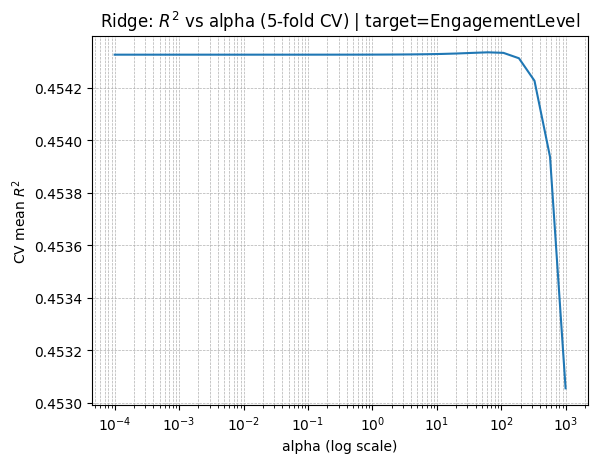

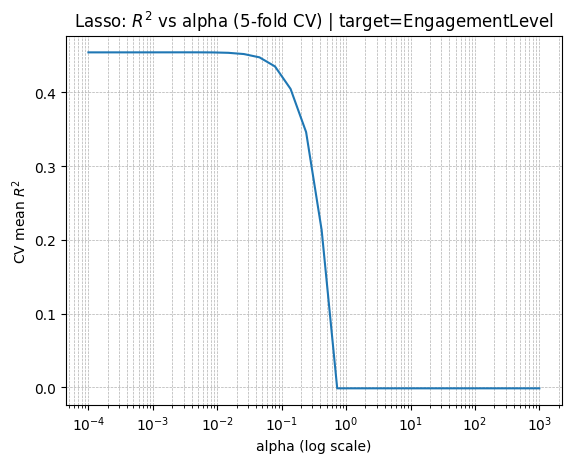


=== REGRESSION FINAL TEST RESULTS ===
                          Model           Target        R2       MSE       MAE
0  Lasso (tuned alpha=0.002807)  EngagementLevel  0.456518  1.090920  0.821302
1      Ridge (tuned alpha=62.1)  EngagementLevel  0.455409  1.093146  0.821434
2                           OLS  EngagementLevel  0.455363  1.093238  0.821355

=== REGRESSION BOOKTABS LaTeX ===
\begin{table}[t]
\centering
\begin{tabular}{llrrr}
\toprule
Model & Target & $R^2$ & MSE & MAE \\
\midrule
Lasso (tuned alpha=0.002807) & EngagementLevel & 0.4565 & 1.0909 & 0.8213 \\
Ridge (tuned alpha=62.1) & EngagementLevel & 0.4554 & 1.0931 & 0.8214 \\
OLS & EngagementLevel & 0.4554 & 1.0932 & 0.8214 \\
\bottomrule
\end{tabular}
\caption{Regression models with standardization (test set). Target: EngagementLevel. Ridge/Lasso tuned via 5-fold CV on training data.}
\label{tab:auto_regression_results}
\end{table}

=== CLASSIFICATION CV (training) | target=Rating ===
F1_macro mean=nan std=nan

=== CLASSI

In [ ]:

#   COSA FA QUESTO CODICE AUTOMATICAMENTE:
#   carica un dataset pulito di giochi (DM1_game_dataset_cleaned.csv):
# - Identifica automaticamente il miglior target (regressione O classificazione)
#   in modo sicuro contro leakage (filtri oggettivi + screening di leakage-like
# - Valuta anche un task di classificazione "Rating" se esiste ed è categorico
# - Per il target di REGRESSIONE selezionato: Standardizza + OLS + ottimizza Ridge/Lasso (griglia alpha)
#   + plot CV R^2 vs alpha + metriche finali test + tabella LaTeX booktabs
# - Per il target di CLASSIFICAZIONE selezionato: Standardizza + Regressione Logistica (baseline)
#   + CV macro-F1 + metriche finali test + tabella LaTeX booktabs
# - Salva ranking e tabelle LaTeX su file


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, make_scorer
)

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression


# =========================
# 0) CONFIG (reproducible)
# =========================
DATA_PATH = "DM1_game_dataset_cleaned.csv"
RANDOM_STATE = 42
TEST_SIZE = 0.30
CV_FOLDS = 5

# Target candidate filters
MAX_MISSING_FRAC = 0.30
MIN_SAMPLES = 500

# Classification filters
MIN_CLASS_SAMPLES = 200
MIN_CLASS_PER_LABEL = 30
MAX_CLASS_CARDINALITY = 10

# ID-like numeric columns (objective heuristic)
ID_UNIQUENESS_THRESHOLD = 0.98

# Leakage-like screening (objective)
LEAK_MAX_ABS_CORR = 0.95            # if target too correlated w/ one predictor -> exclude
LEAK_SINGLE_FEATURE_R2 = 0.80        # if one feature alone yields high CV R2 -> exclude
BINARY_NUMERIC_AS_CLASS = True       # numeric {0,1} treated as classification

# Ridge/Lasso tuning
ALPHAS = np.logspace(-4, 3, 30)
LASSO_MAX_ITER = 200000

# If you want to always compare against "Rating" classification (if present)
FORCE_RATING_CLASSIFICATION = True


=
# 1) LOAD

df = pd.read_csv('./dataset/DM1_game_dataset_cleaned.csv')




# 2) HELPERS

def is_id_like(series: pd.Series, uniqueness_threshold=ID_UNIQUENESS_THRESHOLD) -> bool:
    if not pd.api.types.is_numeric_dtype(series):
        return False
    s = series.dropna()
    if len(s) == 0:
        return False
    return (s.nunique() / len(s)) >= uniqueness_threshold

def mostly_numeric(series: pd.Series, thr=0.95) -> bool:
    coerced = pd.to_numeric(series, errors="coerce")
    return coerced.notna().mean() >= thr

def is_binary_numeric(series: pd.Series) -> bool:
    if not pd.api.types.is_numeric_dtype(series):
        return False
    s = pd.Series(series).dropna().unique()
    return len(s) == 2 and set(s).issubset({0, 1})

def make_booktabs_latex_table(df_metrics, caption, label, digits=4, col_spec=None):
    def fmt(x):
        if isinstance(x, (float, np.floating)):
            return f"{x:.{digits}f}"
        return str(x)

    cols = list(df_metrics.columns)
    if col_spec is None:
        # default: left for first 2, right for numbers
        col_spec = "".join(["l" if i < 2 else "r" for i in range(len(cols))])

    rows = []
    for _, r in df_metrics.iterrows():
        rows.append(" & ".join(fmt(r[c]) for c in cols) + " \\\\")

    header = " & ".join(cols).replace("R2", "$R^2$").replace("F1_macro", "F1$_{macro}$") + " \\\\"

    latex = "\n".join([
        "\\begin{table}[t]",
        "\\centering",
        f"\\begin{{tabular}}{{{col_spec}}}",
        "\\toprule",
        header,
        "\\midrule",
        *rows,
        "\\bottomrule",
        "\\end{tabular}",
        f"\\caption{{{caption}}}",
        f"\\label{{{label}}}",
        "\\end{table}",
    ])
    return latex

def evaluate_regression(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
    }

def evaluate_classification(y_true, y_pred):
    # macro metrics for multi-class robustness
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

def max_abs_corr_with_any_feature(X_num: pd.DataFrame, y_num: pd.Series) -> float:
    joined = X_num.copy()
    joined["_y_"] = y_num.values
    joined = joined.dropna()
    if len(joined) < 100:
        return np.nan
    corrs = joined.drop(columns=["_y_"]).corrwith(joined["_y_"]).abs()
    return float(corrs.max()) if len(corrs) else np.nan

def best_single_feature_r2_cv(X_num: pd.DataFrame, y_num: pd.Series, cv, preprocess) -> float:
    best = -np.inf
    for c in X_num.columns:
        Xi = X_num[[c]]
        model = Pipeline([("prep", preprocess), ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE))])
        scores = cross_val_score_safe(model, Xi, y_num, cv=cv, scoring="r2")
        m = float(np.mean(scores))
        if m > best:
            best = m
    return best

def cross_val_score_safe(estimator, X, y, cv, scoring):
    # wrapper to avoid importing cross_val_score twice if you modify later
    from sklearn.model_selection import cross_val_score
    return cross_val_score(estimator, X, y, cv=cv, scoring=scoring, n_jobs=-1)

# Common preprocessing for numeric predictors
X_preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# CV splitter (reproducible)
cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
f1_macro_scorer = make_scorer(f1_score, average="macro", zero_division=0)

# Numeric predictor space
numeric_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()



# 3) AUTOMATIC TARGET SELECTION (objective + leakage-safe)

name_blacklist_substrings = ["id", "name", "description", "image", "path", "url"]

candidate_targets = []
for col in df.columns:
    low = col.lower()
    if any(tok in low for tok in name_blacklist_substrings):
        continue
    if df[col].notna().sum() == 0:
        continue
    if is_id_like(df[col]):
        continue
    candidate_targets.append(col)

rows = []
excluded = []

for target in candidate_targets:
    y_raw = df[target]
    missing_frac = 1.0 - y_raw.notna().mean()
    if missing_frac > MAX_MISSING_FRAC:
        excluded.append((target, "too_many_missing"))
        continue

    # Decide task
    if pd.api.types.is_numeric_dtype(y_raw) or mostly_numeric(y_raw):
        y_num = pd.to_numeric(y_raw, errors="coerce")
        if BINARY_NUMERIC_AS_CLASS and is_binary_numeric(y_num):
            task = "classification"
            y = y_num.astype(int).astype(str)
        else:
            task = "regression"
            y = y_num.astype(float)
    else:
        task = "classification"
        y = y_raw.astype(str)

    # Build numeric X excluding target if present
    X_cols = numeric_cols_all.copy()
    if target in X_cols:
        X_cols.remove(target)
    if len(X_cols) < 2:
        excluded.append((target, "not_enough_numeric_predictors"))
        continue

    X = df[X_cols]
    valid = y.notna()
    X = X.loc[valid]
    y = y.loc[valid]

    if len(y) < MIN_SAMPLES:
        excluded.append((target, "too_few_samples"))
        continue

    if task == "regression":
        if np.nanvar(y.values) < 1e-6:
            excluded.append((target, "near_constant_target"))
            continue

        # leakage-like screening
        max_corr = max_abs_corr_with_any_feature(X, y)
        best1f = best_single_feature_r2_cv(X, y, cv=cv, preprocess=X_preprocess)

        if (not np.isnan(max_corr) and max_corr >= LEAK_MAX_ABS_CORR) or (best1f >= LEAK_SINGLE_FEATURE_R2):
            excluded.append((target, f"leakage_like(max_corr={max_corr:.3f}, best1fR2={best1f:.3f})"))
            continue

        ridge = Pipeline([("prep", X_preprocess), ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE))])
        scores = cross_val_score_safe(ridge, X, y, cv=cv, scoring="r2")

        rows.append({
            "target": target,
            "task": "regression",
            "cv_metric": "R2",
            "cv_mean": float(np.mean(scores)),
            "cv_std": float(np.std(scores)),
            "n": int(len(y)),
            "missing_frac": float(missing_frac),
            "n_unique": int(pd.Series(y).nunique()),
            "max_abs_corr": float(max_corr) if not np.isnan(max_corr) else np.nan,
            "best_single_feature_r2": float(best1f),
        })

    else:
        n_unique = y.nunique()
        if n_unique < 2 or n_unique > MAX_CLASS_CARDINALITY:
            excluded.append((target, "bad_cardinality_for_classification"))
            continue

        vc = y.value_counts()
        if len(y) < MIN_CLASS_SAMPLES or vc.min() < MIN_CLASS_PER_LABEL:
            excluded.append((target, "too_imbalanced_or_small_class"))
            continue

        clf = Pipeline([
            ("prep", X_preprocess),
            ("model", LogisticRegression(max_iter=5000, solver="lbfgs", random_state=RANDOM_STATE))
        ])
        scores = cross_val_score_safe(clf, X, y, cv=cv, scoring=f1_macro_scorer)

        rows.append({
            "target": target,
            "task": "classification",
            "cv_metric": "F1_macro",
            "cv_mean": float(np.mean(scores)),
            "cv_std": float(np.std(scores)),
            "n": int(len(y)),
            "missing_frac": float(missing_frac),
            "n_unique": int(n_unique),
            "min_class": int(vc.min()),
            "max_class": int(vc.max()),
        })

ranking = pd.DataFrame(rows).sort_values("cv_mean", ascending=False).reset_index(drop=True)
excluded_df = pd.DataFrame(excluded, columns=["target", "reason"]).sort_values("reason")

ranking.to_csv("target_selection_ranking_safe.csv", index=False)
excluded_df.to_csv("target_selection_excluded.csv", index=False)

if ranking.empty:
    raise RuntimeError("No valid targets found. Relax thresholds or review dataset columns.")

best_overall = ranking.iloc[0]
print("\n=== BEST OVERALL TARGET (auto, leakage-safe) ===")
print(best_overall.to_string())

# Also pick best regression target and best classification target (if available)
best_reg = ranking[ranking["task"] == "regression"].head(1)
best_clf = ranking[ranking["task"] == "classification"].head(1)

best_reg_target = best_reg.iloc[0]["target"] if len(best_reg) else None
best_clf_target = best_clf.iloc[0]["target"] if len(best_clf) else None

print("\nBest regression target:", best_reg_target)
print("Best classification target:", best_clf_target)


# 4) DEFINE PREDICTORS X (numeric only) FOR MODELING

def make_X_y_for_target(target_col):
    # Decide y type again for modeling
    y_raw = df[target_col]
    if pd.api.types.is_numeric_dtype(y_raw) or mostly_numeric(y_raw):
        y_num = pd.to_numeric(y_raw, errors="coerce")
        if BINARY_NUMERIC_AS_CLASS and is_binary_numeric(y_num):
            task = "classification"
            y = y_num.astype(int).astype(str)
        else:
            task = "regression"
            y = y_num.astype(float)
    else:
        task = "classification"
        y = y_raw.astype(str)

    X_cols = numeric_cols_all.copy()
    if target_col in X_cols:
        X_cols.remove(target_col)

    X = df[X_cols]
    valid = y.notna()
    return task, X.loc[valid], y.loc[valid], X_cols


# =========================
# 5) REGRESSION MODELING (OLS + tuned Ridge/Lasso) FOR best_reg_target
# =========================
regression_outputs = {}
if best_reg_target is not None:
    task, X, y, X_cols = make_X_y_for_target(best_reg_target)
    if task != "regression":
        print(f"\n[Skip regression] best_reg_target={best_reg_target} is not regression after typing.")
    else:
        # Train/test split (reproducible)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
        )

        # Pipelines
        ols = Pipeline([("prep", X_preprocess), ("model", LinearRegression())])
        ridge_pipe = Pipeline([("prep", X_preprocess), ("model", Ridge(random_state=RANDOM_STATE))])
        lasso_pipe = Pipeline([("prep", X_preprocess), ("model", Lasso(random_state=RANDOM_STATE, max_iter=LASSO_MAX_ITER))])

        # OLS test eval
        ols.fit(X_train, y_train)
        pred_ols = ols.predict(X_test)
        met_ols = evaluate_regression(y_test, pred_ols)

        # GridSearchCV for Ridge/Lasso (CV on training only)
        ridge_gs = GridSearchCV(
            ridge_pipe, {"model__alpha": ALPHAS}, scoring="r2", cv=cv, n_jobs=-1, error_score="raise"
        )
        lasso_gs = GridSearchCV(
            lasso_pipe, {"model__alpha": ALPHAS}, scoring="r2", cv=cv, n_jobs=-1, error_score="raise"
        )

        ridge_gs.fit(X_train, y_train)
        lasso_gs.fit(X_train, y_train)

        best_ridge = ridge_gs.best_estimator_
        best_lasso = lasso_gs.best_estimator_

        # Test eval tuned models
        pred_ridge = best_ridge.predict(X_test)
        pred_lasso = best_lasso.predict(X_test)
        met_ridge = evaluate_regression(y_test, pred_ridge)
        met_lasso = evaluate_regression(y_test, pred_lasso)

        # CV curves
        ridge_cv = pd.DataFrame(ridge_gs.cv_results_)[["param_model__alpha", "mean_test_score"]].sort_values("param_model__alpha")
        lasso_cv = pd.DataFrame(lasso_gs.cv_results_)[["param_model__alpha", "mean_test_score"]].sort_values("param_model__alpha")

        plt.figure()
        plt.semilogx(ridge_cv["param_model__alpha"].astype(float), ridge_cv["mean_test_score"].astype(float))
        plt.xlabel("alpha (log scale)")
        plt.ylabel("CV mean $R^2$")
        plt.title(f"Ridge: $R^2$ vs alpha (5-fold CV) | target={best_reg_target}")
        plt.grid(True, which="both", linestyle="--", linewidth=0.5)
        plt.show()

        plt.figure()
        plt.semilogx(lasso_cv["param_model__alpha"].astype(float), lasso_cv["mean_test_score"].astype(float))
        plt.xlabel("alpha (log scale)")
        plt.ylabel("CV mean $R^2$")
        plt.title(f"Lasso: $R^2$ vs alpha (5-fold CV) | target={best_reg_target}")
        plt.grid(True, which="both", linestyle="--", linewidth=0.5)
        plt.show()

        # Build final metrics table
        reg_results = pd.DataFrame([
            {"Model": "OLS", "Target": best_reg_target, **met_ols},
            {"Model": f"Ridge (tuned alpha={ridge_gs.best_params_['model__alpha']:.4g})", "Target": best_reg_target, **met_ridge},
            {"Model": f"Lasso (tuned alpha={lasso_gs.best_params_['model__alpha']:.4g})", "Target": best_reg_target, **met_lasso},
        ]).sort_values("R2", ascending=False).reset_index(drop=True)

        print("\n=== REGRESSION FINAL TEST RESULTS ===")
        print(reg_results)

        reg_latex = make_booktabs_latex_table(
            reg_results[["Model", "Target", "R2", "MSE", "MAE"]],
            caption=f"Regression models with standardization (test set). Target: {best_reg_target}. "
                    f"Ridge/Lasso tuned via {CV_FOLDS}-fold CV on training data.",
            label="tab:auto_regression_results",
            digits=4
        )
        print("\n=== REGRESSION BOOKTABS LaTeX ===")
        print(reg_latex)

        reg_results.to_csv("regression_results.csv", index=False)
        with open("regression_results_table.tex", "w", encoding="utf-8") as f:
            f.write(reg_latex)

        regression_outputs = {
            "target": best_reg_target,
            "ridge_best_alpha": ridge_gs.best_params_["model__alpha"],
            "lasso_best_alpha": lasso_gs.best_params_["model__alpha"],
            "results_df": reg_results,
            "latex": reg_latex
        }



# 6) CLASSIFICATION MODELING
#    - Prefer "Rating" if exists and is categorical and FORCE_RATING_CLASSIFICATION=True
#    - Otherwise use best_clf_target if available

clf_target_to_use = None
if FORCE_RATING_CLASSIFICATION and "Rating" in df.columns and not mostly_numeric(df["Rating"]):
    clf_target_to_use = "Rating"
elif best_clf_target is not None:
    clf_target_to_use = best_clf_target

classification_outputs = {}
if clf_target_to_use is not None:
    task, X, y, X_cols = make_X_y_for_target(clf_target_to_use)
    if task != "classification":
        print(f"\n[Skip classification] {clf_target_to_use} is not classification after typing.")
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
        )

        clf = Pipeline([
            ("prep", X_preprocess),
            ("model", LogisticRegression(max_iter=5000, solver="lbfgs", random_state=RANDOM_STATE))
        ])

        # CV macro-F1 on training
        cv_scores = cross_val_score_safe(clf, X_train, y_train, cv=cv, scoring=f1_macro_scorer)
        print(f"\n=== CLASSIFICATION CV (training) | target={clf_target_to_use} ===")
        print(f"F1_macro mean={np.mean(cv_scores):.4f} std={np.std(cv_scores):.4f}")

        # Fit + test metrics
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        met = evaluate_classification(y_test, y_pred)

        # Confusion matrix (printed)
        cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
        print("\n=== CLASSIFICATION TEST RESULTS ===")
        print(pd.DataFrame([{"Model": "LogReg (std)", "Target": clf_target_to_use, **met}]))

        print("\nConfusion matrix (rows=true, cols=pred) with labels:", sorted(y.unique()))
        print(cm)

        clf_results = pd.DataFrame([
            {"Model": "LogReg (std)", "Target": clf_target_to_use, **met,
             "CV_F1_macro_mean": float(np.mean(cv_scores)), "CV_F1_macro_std": float(np.std(cv_scores))}
        ])

        clf_latex = make_booktabs_latex_table(
            clf_results[["Model", "Target", "Accuracy", "Precision_macro", "Recall_macro", "F1_macro", "CV_F1_macro_mean", "CV_F1_macro_std"]],
            caption=f"Classification with standardized features (test set). Target: {clf_target_to_use}. "
                    f"CV performed on training set with {CV_FOLDS}-fold macro-F1.",
            label="tab:auto_classification_results",
            digits=4,
            col_spec="llrrrrrr"
        )

        print("\n=== CLASSIFICATION BOOKTABS LaTeX ===")
        print(clf_latex)

        clf_results.to_csv("classification_results.csv", index=False)
        with open("classification_results_table.tex", "w", encoding="utf-8") as f:
            f.write(clf_latex)

        classification_outputs = {
            "target": clf_target_to_use,
            "cv_f1_mean": float(np.mean(cv_scores)),
            "cv_f1_std": float(np.std(cv_scores)),
            "results_df": clf_results,
            "latex": clf_latex,
            "confusion_matrix": cm
        }
else:
    print("\nNo suitable classification target found (or Rating not available/valid).")


# =========================
# 7) FINAL SUMMARY PRINTS
# =========================
print("\n=========================")
print("PIPELINE SUMMARY")
print("=========================")
print("Saved target ranking:", "target_selection_ranking_safe.csv")
print("Saved exclusions:", "target_selection_excluded.csv")

if regression_outputs:
    print(f"- Regression target: {regression_outputs['target']}")
    print(f"  Ridge best alpha: {regression_outputs['ridge_best_alpha']}")
    print(f"  Lasso best alpha: {regression_outputs['lasso_best_alpha']}")
    print("  Saved: regression_results.csv, regression_results_table.tex")
else:
    print("- Regression: not executed.")

if classification_outputs:
    print(f"- Classification target: {classification_outputs['target']}")
    print(f"  CV F1_macro mean/std: {classification_outputs['cv_f1_mean']:.4f}/{classification_outputs['cv_f1_std']:.4f}")
    print("  Saved: classification_results.csv, classification_results_table.tex")
else:
    print("- Classification: not executed.")


# Linear regression (Leo)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.model_selection import train_test_split

In [2]:
d= pd.read_csv('./dataset/DM1_game_dataset_cleaned.csv')
# filter df for numeric columns only
df = d.select_dtypes(include=[np.number])
# exclude binary columns
df = df.loc[:, df.nunique() > 2]

X = df.values
df.head()

,YearPublished,GameWeight,MinPlayers,MaxPlayers,MfgPlaytime,MfgAgeRec,NumAlternates,NumExpansions,NumImplementations,Rank,EngagementLevel
0,2014,1.8333,2,4,30,15,0.000000,0.693147,0.0,21926,4.744932
1,2021,1.0000,2,5,20,8,0.693147,0.000000,0.0,21926,3.772761
2,2020,3.6667,1,5,150,12,0.000000,0.693147,0.0,21926,4.997212
3,2004,1.3077,2,2,20,10,0.000000,0.000000,0.0,21926,3.806662
4,2019,1.5000,2,4,20,8,1.386294,0.000000,0.0,21926,4.060443


In [3]:
df_train, df_test = train_test_split(d, test_size=0.3, random_state=100)

## 1. Simple Regression

In [4]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso

In [5]:
# fit each x variable with y and find tthe best R2
for col in df.columns:
    x_train = df_train[col].values.reshape(-1, 1) # independent variables
    y_train = df_train["EngagementLevel"].values # target variable

    x_test = df_test[col].values.reshape(-1, 1)
    y_test = df_test["EngagementLevel"].values

    reg = LinearRegression()
    reg.fit(x_train, y_train)

    y_pred = reg.predict(x_test)

    print(f'Column: {col}')
    print('R2: %.3f' % r2_score(y_test, y_pred))
    print('MSE: %.3f' % mean_squared_error(y_test, y_pred))
    print('MAE: %.3f' % mean_absolute_error(y_test, y_pred))
    print('-------------------')

Column: YearPublished
R2: 0.004
MSE: 1.984
MAE: 1.122
-------------------
Column: GameWeight
R2: 0.044
MSE: 1.904
MAE: 1.097
-------------------
Column: MinPlayers
R2: 0.006
MSE: 1.980
MAE: 1.121
-------------------
Column: MaxPlayers
R2: 0.000
MSE: 1.992
MAE: 1.124
-------------------
Column: MfgPlaytime
R2: -0.000
MSE: 1.992
MAE: 1.124
-------------------
Column: MfgAgeRec
R2: 0.024
MSE: 1.945
MAE: 1.108
-------------------
Column: NumAlternates
R2: 0.157
MSE: 1.679
MAE: 1.040
-------------------
Column: NumExpansions
R2: 0.170
MSE: 1.653
MAE: 1.021
-------------------
Column: NumImplementations
R2: 0.070
MSE: 1.852
MAE: 1.085
-------------------
Column: Rank
R2: 0.209
MSE: 1.575
MAE: 0.989
-------------------
Column: EngagementLevel
R2: 1.000
MSE: 0.000
MAE: 0.000
-------------------


In [6]:
# log-scale of MfgPlaytime

x_train = df_train["NumExpansions"].values.reshape(-1, 1) # independent variables
y_train = df_train["EngagementLevel"].values # target variable

x_test = df_test["NumExpansions"].values.reshape(-1, 1)
y_test = df_test["EngagementLevel"].values

<Axes: xlabel='NumExpansions', ylabel='EngagementLevel'>

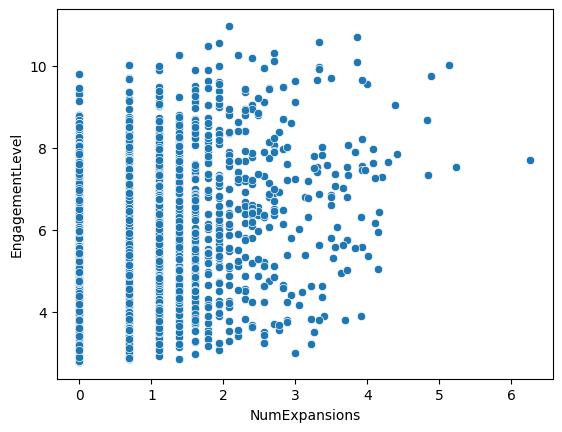

In [7]:
# scatterplot gameweight vs mfgplaytime
sns.scatterplot(data=df_test, x="NumExpansions", y="EngagementLevel")


### Linear Regression

In [8]:
reg = LinearRegression()
reg.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
print('Coefficients: \n', reg.coef_)
print('Intercept: \n', reg.intercept_)

Coefficients: 
 [0.81599195]
Intercept: 
 4.519192233589627


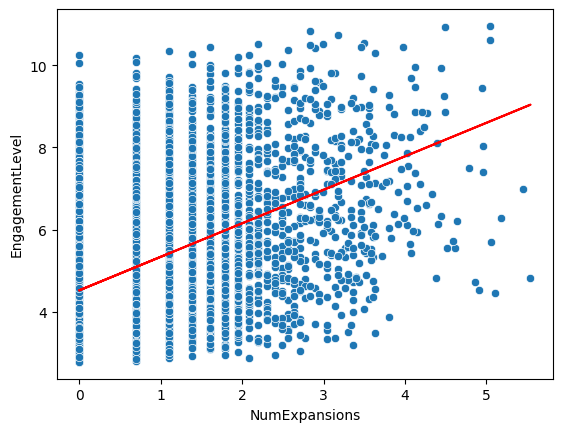

In [10]:
sns.scatterplot(data=df_train, x="NumExpansions", y="EngagementLevel")
plt.plot(x_train, reg.coef_[0]*x_train+reg.intercept_, c="red")

In [11]:
y_pred = reg.predict(x_test)

print('R2: %.3f' % r2_score(y_test, y_pred))
print('MSE: %.3f' % mean_squared_error(y_test, y_pred))
print('MAE: %.3f' % mean_absolute_error(y_test, y_pred))

R2: 0.170
MSE: 1.653
MAE: 1.021


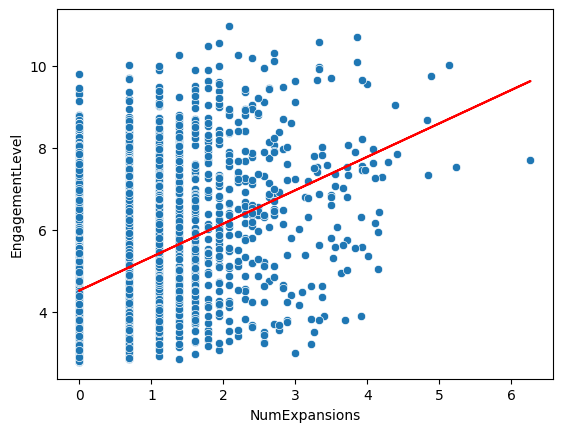

In [12]:
sns.scatterplot(data=df_test, x="NumExpansions", y="EngagementLevel")
plt.plot(x_test, reg.coef_[0]*x_test+reg.intercept_, c="red")

### Ridge

In [13]:
reg = Ridge()
reg.fit(x_train, y_train)
print('Coefficients: \n', reg.coef_)
print('Intercept: \n', reg.intercept_)

Coefficients: 
 [0.8158856]
Intercept: 
 4.5192283177668235


In [14]:
# evaluate the pruned model
y_pred = reg.predict(x_test)
print('R2: %.3f' % r2_score(y_test, y_pred))
print('MSE: %.3f' % mean_squared_error(y_test, y_pred))
print('MAE: %.3f' % mean_absolute_error(y_test, y_pred))

R2: 0.170
MSE: 1.653
MAE: 1.021


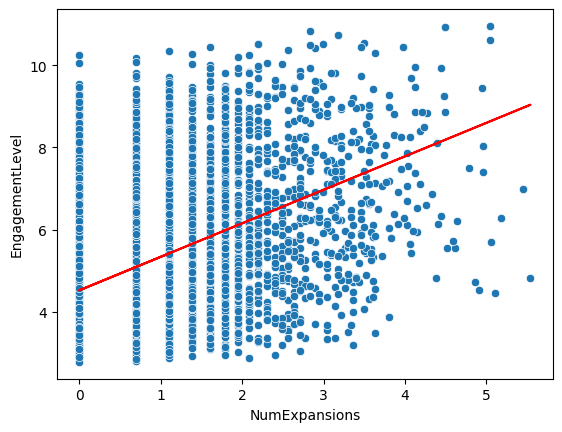

In [15]:
sns.scatterplot(data=df_train, x="NumExpansions", y="EngagementLevel")
plt.plot(x_train, reg.coef_[0]*x_train+reg.intercept_, c="red")

### Lasso

In [16]:
reg = Lasso()
reg.fit(x_train, y_train)
print('Coefficients: \n', reg.coef_)
print('Intercept: \n', reg.intercept_)

Coefficients: 
 [0.]
Intercept: 
 4.796067837352542


In [17]:
# evaluate the pruned model
y_pred = reg.predict(x_test)
print('R2: %.3f' % r2_score(y_test, y_pred))
print('MSE: %.3f' % mean_squared_error(y_test, y_pred))
print('MAE: %.3f' % mean_absolute_error(y_test, y_pred))


R2: -0.000
MSE: 1.992
MAE: 1.124


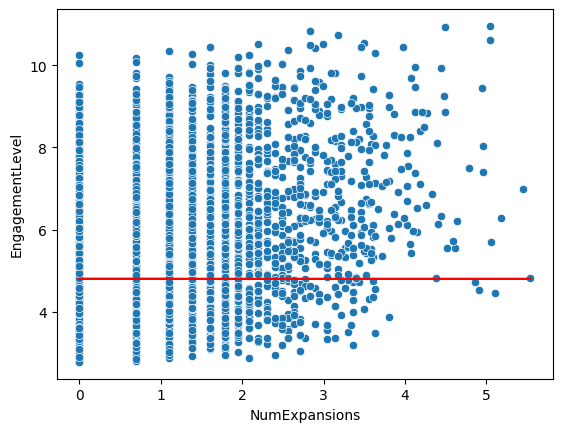

In [18]:
sns.scatterplot(data=df_train, x="NumExpansions", y="EngagementLevel")
plt.plot(x_train, reg.coef_[0]*x_train+reg.intercept_, c="red")

## 2. Non-Linear Regression

### Decision Tree

In [19]:
from sklearn.tree import DecisionTreeRegressor

In [20]:
reg = DecisionTreeRegressor()

In [21]:
for col in df.columns:
    x_train = df_train[col].values.reshape(-1, 1) # independent variables
    y_train = df_train["EngagementLevel"].values # target variable

    x_test = df_test[col].values.reshape(-1, 1)
    y_test = df_test["EngagementLevel"].values

    reg = DecisionTreeRegressor()
    reg.fit(x_train, y_train)

    y_pred = reg.predict(x_test)

    print(f'Column: {col}')
    print('R2: %.3f' % r2_score(y_test, y_pred))
    print('MSE: %.3f' % mean_squared_error(y_test, y_pred))
    print('MAE: %.3f' % mean_absolute_error(y_test, y_pred))
    print('-------------------')

Column: YearPublished
R2: 0.013
MSE: 1.967
MAE: 1.109
-------------------
Column: GameWeight
R2: 0.389
MSE: 1.218
MAE: 0.817
-------------------
Column: MinPlayers
R2: 0.011
MSE: 1.971
MAE: 1.118
-------------------
Column: MaxPlayers
R2: 0.027
MSE: 1.939
MAE: 1.103
-------------------
Column: MfgPlaytime
R2: 0.035
MSE: 1.922
MAE: 1.102
-------------------
Column: MfgAgeRec
R2: 0.043
MSE: 1.906
MAE: 1.094
-------------------
Column: NumAlternates
R2: 0.156
MSE: 1.682
MAE: 1.039
-------------------
Column: NumExpansions
R2: 0.164
MSE: 1.665
MAE: 1.020
-------------------
Column: NumImplementations
R2: 0.073
MSE: 1.847
MAE: 1.083
-------------------
Column: Rank
R2: 0.211
MSE: 1.572
MAE: 0.976
-------------------
Column: EngagementLevel
R2: 1.000
MSE: 0.000
MAE: 0.000
-------------------


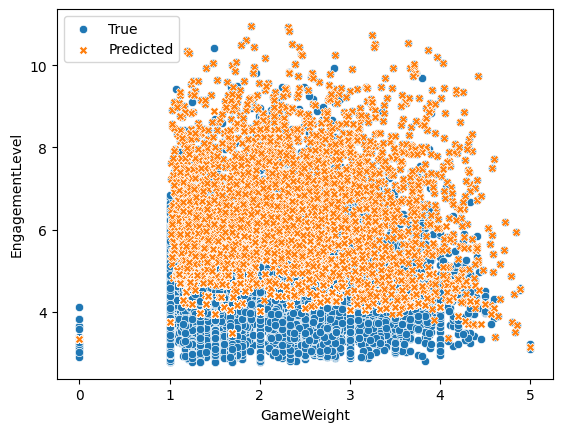

In [22]:
x_train = df_train["GameWeight"].values.reshape(-1, 1) # independent variables
y_train = df_train["EngagementLevel"].values # target variable

x_test = df_test["GameWeight"].values.reshape(-1, 1)
y_test = df_test["EngagementLevel"].values

reg = DecisionTreeRegressor()
reg.fit(x_train, y_train)


sns.scatterplot(data=df_train, x="GameWeight", y="EngagementLevel", label="True")
sns.scatterplot(data=df_train, x="GameWeight", y=reg.predict(x_train), label="Predicted", marker="X")
plt.legend()
plt.show()

### K-NN Regressor

In [23]:
from sklearn.neighbors import KNeighborsRegressor

In [24]:
for col in df.columns:
    x_train = df_train[col].values.reshape(-1, 1) # independent variables
    y_train = df_train["EngagementLevel"].values # target variable

    x_test = df_test[col].values.reshape(-1, 1)
    y_test = df_test["EngagementLevel"].values

    reg = KNeighborsRegressor(n_neighbors=4)
    reg.fit(x_train, y_train)

    y_pred = reg.predict(x_test)

    print(f'Column: {col}')
    print('R2: %.3f' % r2_score(y_test, y_pred))
    print('MSE: %.3f' % mean_squared_error(y_test, y_pred))
    print('MAE: %.3f' % mean_absolute_error(y_test, y_pred))
    print('-------------------')    

Column: YearPublished
R2: -0.245
MSE: 2.481
MAE: 1.244
-------------------
Column: GameWeight
R2: 0.384
MSE: 1.227
MAE: 0.830
-------------------
Column: MinPlayers
R2: -0.068
MSE: 2.127
MAE: 1.124
-------------------
Column: MaxPlayers
R2: -0.194
MSE: 2.378
MAE: 1.237
-------------------
Column: MfgPlaytime
R2: -0.379
MSE: 2.748
MAE: 1.321
-------------------
Column: MfgAgeRec
R2: -0.194
MSE: 2.379
MAE: 1.234
-------------------
Column: NumAlternates
R2: 0.103
MSE: 1.786
MAE: 1.069
-------------------
Column: NumExpansions
R2: 0.105
MSE: 1.784
MAE: 1.026
-------------------
Column: NumImplementations
R2: -0.042
MSE: 2.076
MAE: 1.074
-------------------
Column: Rank
R2: 0.284
MSE: 1.427
MAE: 0.922
-------------------
Column: EngagementLevel
R2: 1.000
MSE: 0.000
MAE: 0.000
-------------------


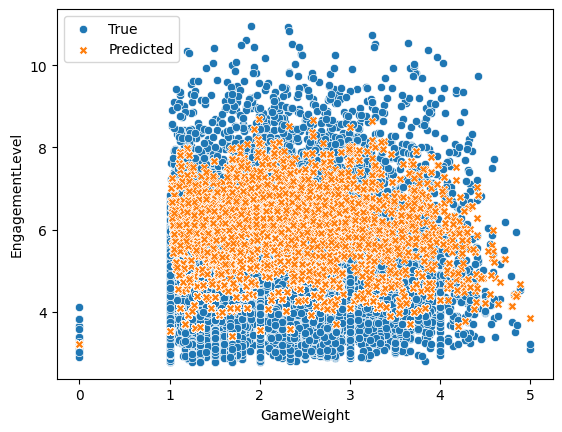

In [25]:
x_train = df_train["GameWeight"].values.reshape(-1, 1) # independent variables
y_train = df_train["EngagementLevel"].values # target variable

x_test = df_test["GameWeight"].values.reshape(-1, 1)
y_test = df_test["EngagementLevel"].values

reg = KNeighborsRegressor(n_neighbors=4)

reg.fit(x_train, y_train)

sns.scatterplot(data=df_train, x="GameWeight", y="EngagementLevel", label="True")
sns.scatterplot(data=df_train, x="GameWeight", y=reg.predict(x_train), label="Predicted", marker="X")
plt.legend()
plt.show()

# 3. Multiple Regression

In [26]:
from sklearn.preprocessing import StandardScaler
cols = [f for f in df.columns if f not in ["EngagementLevel"]]
X_train = df_train[cols].values
X_train_scaled = StandardScaler().fit_transform(X_train)
y_train = df_train["EngagementLevel"].values

X_test = df_test[cols].values
X_test_scaled = StandardScaler().fit_transform(X_test)
y_test = df_test["EngagementLevel"].values

### Linear Regression

In [27]:
reg = LinearRegression()
reg.fit(X_train_scaled, y_train)
print('Coefficients: \n', reg.coef_)
print('Intercept: \n', reg.intercept_)

Coefficients: 
 [ 0.09684649  0.04702234 -0.03215549  0.00421101 -0.02059568  0.18217795
  0.48373305  0.37860735  0.14988864 -0.43958561]
Intercept: 
 4.796067837352542


In [28]:
y_pred = reg.predict(X_test_scaled)
print('R2: %.5f' % r2_score(y_test, y_pred))
print('MSE: %.5f' % mean_squared_error(y_test, y_pred))
print('MAE: %.5f' % mean_absolute_error(y_test, y_pred))

R2: 0.44963
MSE: 1.09640
MAE: 0.83338


### Ridge

In [29]:
reg = Ridge(alpha=1.0)
reg.fit(X_train_scaled, y_train)
print('Coefficients: \n', reg.coef_)
print('Intercept: \n', reg.intercept_)

Coefficients: 
 [ 0.09683818  0.04703484 -0.03215396  0.00421123 -0.0205948   0.18215956
  0.48370422  0.37858939  0.14989103 -0.43956355]
Intercept: 
 4.796067837352542


In [30]:
y_pred = reg.predict(X_test_scaled)
print('R2: %.5f' % r2_score(y_test, y_pred))
print('MSE: %.5f' % mean_squared_error(y_test, y_pred))
print('MAE: %.5f' % mean_absolute_error(y_test, y_pred))

R2: 0.44963
MSE: 1.09640
MAE: 0.83338


In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
# ==========================================
# B. RIDGE CV (L2 Regularization)
# ==========================================
print("\n--- Training RidgeCV ---")
# RidgeCV richiede spesso di specificare un range di alpha da provare
alphas_to_test = np.logspace(-4, 4, 100) # Crea 100 valori da 0.0001 a 10000

ridge = RidgeCV(alphas=alphas_to_test, scoring='neg_mean_squared_error', cv=10)
ridge.fit(X_train_scaled, y_train)

print(f"Miglior Alpha trovato (Ridge): {ridge.alpha_}")

y_pred_ridge = ridge.predict(X_test_scaled)
print(f"Ridge R2: {r2_score(y_test, y_pred_ridge):.3f}")
print(f"Ridge MSE: {mean_squared_error(y_test, y_pred_ridge):.3f}")
print(f"Ridge MAE: {mean_absolute_error(y_test, y_pred_ridge):.3f}")


--- Training RidgeCV ---


Miglior Alpha trovato (Ridge): 200.923300256505
Ridge R2: 0.450
Ridge MSE: 1.096
Ridge MAE: 0.834


### Lasso

In [32]:
reg = Lasso()
reg.fit(X_train_scaled, y_train)
print('Coefficients: \n', reg.coef_)
print('Intercept: \n', reg.intercept_)

Coefficients: 
 [ 0.  0. -0. -0.  0.  0.  0.  0.  0. -0.]
Intercept: 
 4.796067837352542


In [33]:
y_pred = reg.predict(X_test_scaled)
print('R2: %.5f' % r2_score(y_test, y_pred))
print('MSE: %.5f' % mean_squared_error(y_test, y_pred))
print('MAE: %.5f' % mean_absolute_error(y_test, y_pred))

R2: -0.00017
MSE: 1.99246
MAE: 1.12394


In [36]:
from sklearn.linear_model import LassoCV
#  A. LASSO CV (L1 Regularization)
# ==========================================
print("--- Training LassoCV ---")
# LassoCV cercherà l'alpha migliore tra una lista automatica (o specificata da noi)
# cv=5 significa 5-fold cross-validation
lasso = LassoCV(alphas=None, cv=10, random_state=42, max_iter=10000)

# Scaliamo i dati PRIMA del fit (usando i valori del train)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit
lasso.fit(X_train_scaled, y_train)

# Risultati
print(f"Miglior Alpha trovato (Lasso): {lasso.alpha_}")
print(f"Coefficienti azzerati: {np.sum(lasso.coef_ == 0)} su {len(lasso.coef_)}")
print(f"Coefficiente portato a zero: {lasso.coef_}")
print("The variables removed by Lasso (zero coefficients):")
for i, coef in enumerate(lasso.coef_):
    if coef == 0:
        print(f"- {cols[i]}")

# Predizione
y_pred_lasso = lasso.predict(X_test_scaled)
print(f"Lasso R2: {r2_score(y_test, y_pred_lasso):.3f}")
print(f"Lasso MSE: {mean_squared_error(y_test, y_pred_lasso):.3f}")
print(f"Lasso MAE: {mean_absolute_error(y_test, y_pred_lasso):.3f}")

--- Training LassoCV ---


c:\Users\leona\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1641: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(


Miglior Alpha trovato (Lasso): 0.009522987283754796
Coefficienti azzerati: 1 su 10
Coefficiente portato a zero: [ 0.08698244  0.04098116 -0.02370705  0.         -0.00962192  0.17352915
  0.47209194  0.3761036   0.14379154 -0.43667485]
The variables removed by Lasso (zero coefficients):
- MaxPlayers
Lasso R2: 0.448
Lasso MSE: 1.100
Lasso MAE: 0.836


### Non-linear Regression

Decision Tree

In [ ]:
reg = DecisionTreeRegressor()

In [ ]:
reg.fit(X_train_scaled, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [ ]:
y_pred = reg.predict(X_test_scaled)
print('R2: %.3f' % r2_score(y_test, y_pred))
print('MSE: %.3f' % mean_squared_error(y_test, y_pred))
print('MAE: %.3f' % mean_absolute_error(y_test, y_pred))

R2: 0.456
MSE: 1.085
MAE: 0.780


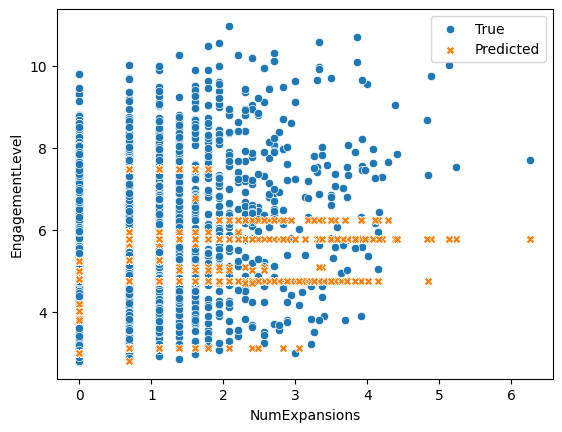

In [ ]:
sns.scatterplot(data=df_test, x="NumExpansions", y="EngagementLevel", label="True")
sns.scatterplot(data=df_test, x="NumExpansions", y=reg.predict(X_test), label="Predicted", marker="X")
plt.legend()
plt.show()

K-NN

In [ ]:
reg = KNeighborsRegressor(n_neighbors=16)

In [ ]:
reg.fit(X_train_scaled, y_train)

,n_neighbors,16
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [ ]:
y_pred = reg.predict(X_test_scaled)
print('R2: %.3f' % r2_score(y_test, y_pred))
print('MSE: %.3f' % mean_squared_error(y_test, y_pred))
print('MAE: %.3f' % mean_absolute_error(y_test, y_pred))

R2: 0.537
MSE: 0.923
MAE: 0.749


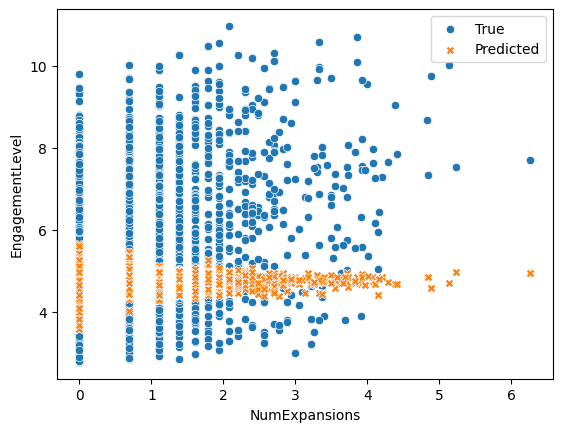

In [ ]:
sns.scatterplot(data=df_test, x="NumExpansions", y="EngagementLevel", label="True")
sns.scatterplot(data=df_test, x="NumExpansions", y=reg.predict(X_test), label="Predicted", marker="X")
plt.legend()
plt.show()